In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Website categories
sites = ["Home", "Search", "News", "Shopping", "YouTube", "Social", "Wikipedia", "Exit"]

# Realistic transition probabilities
P = np.array([
    [0.05,0.35,0.10,0.15,0.15,0.15,0.05,0.00],  # Home
    [0.10,0.10,0.20,0.20,0.15,0.15,0.05,0.05],  # Search
    [0.10,0.20,0.30,0.05,0.10,0.10,0.10,0.05],  # News
    [0.10,0.20,0.05,0.35,0.10,0.10,0.05,0.05],  # Shopping
    [0.10,0.15,0.05,0.10,0.35,0.15,0.05,0.05],  # YouTube
    [0.10,0.20,0.10,0.10,0.20,0.20,0.05,0.05],  # Social
    [0.10,0.30,0.15,0.05,0.10,0.10,0.15,0.05],  # Wikipedia
    [0,0,0,0,0,0,0,1]                            # Exit
])

# Generate 1000 browsing sessions
sessions = []

for _ in range(1000):
    current = 0
    session = [sites[current]]

    for _ in range(15):
        current = np.random.choice(len(sites), p=P[current])
        session.append(sites[current])
        if sites[current] == "Exit":
            break

    sessions.append(session)

print("Sessions generated:", len(sessions))
print("Example:", " → ".join(sessions[0]))


Sessions generated: 1000
Example: Home → Search → Exit


Transition Probability Matrix:


,Home,Search,News,Shopping,YouTube,Social,Wikipedia,Exit
Home,0.050,0.357,0.106,0.146,0.142,0.143,0.055,0.000
Search,0.110,0.101,0.193,0.195,0.156,0.140,0.049,0.057
News,0.094,0.194,0.341,0.042,0.089,0.099,0.102,0.038
Shopping,0.102,0.193,0.050,0.361,0.100,0.094,0.059,0.041
YouTube,0.106,0.149,0.053,0.099,0.343,0.160,0.048,0.041
Social,0.087,0.228,0.096,0.111,0.195,0.195,0.048,0.040
Wikipedia,0.103,0.298,0.134,0.050,0.095,0.101,0.171,0.049
Exit,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


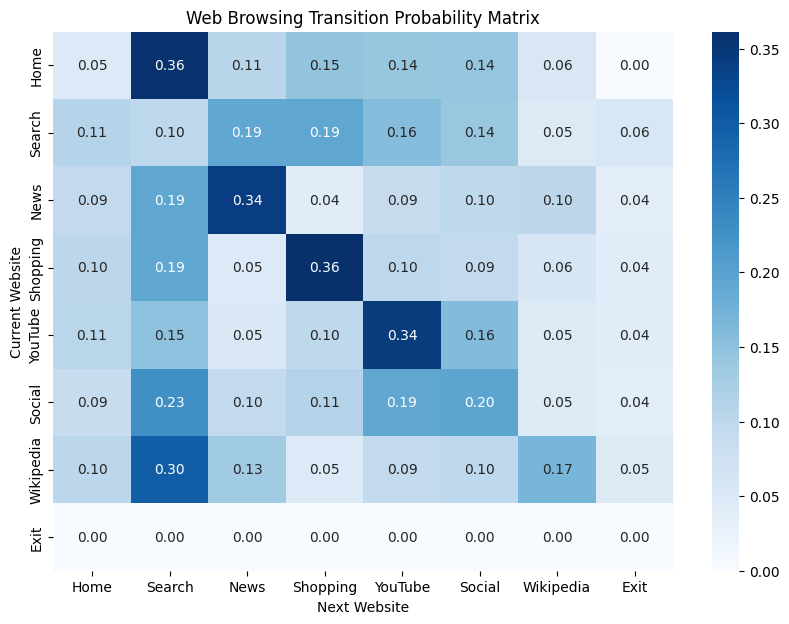

In [2]:
# Count transitions
counts = pd.DataFrame(0, index=sites, columns=sites)

for session in sessions:
    for a, b in zip(session[:-1], session[1:]):
        counts.loc[a, b] += 1

# Convert counts to probabilities
transition_matrix = counts.div(counts.sum(axis=1), axis=0).fillna(0)

print("Transition Probability Matrix:")
display(transition_matrix.round(3))

# Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(transition_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Web Browsing Transition Probability Matrix")
plt.xlabel("Next Website")
plt.ylabel("Current Website")
plt.show()


Long-term browsing distribution:


,0
Search,0.195
YouTube,0.170
Shopping,0.156
News,0.140
Social,0.135
Home,0.096
Wikipedia,0.067
Exit,0.040


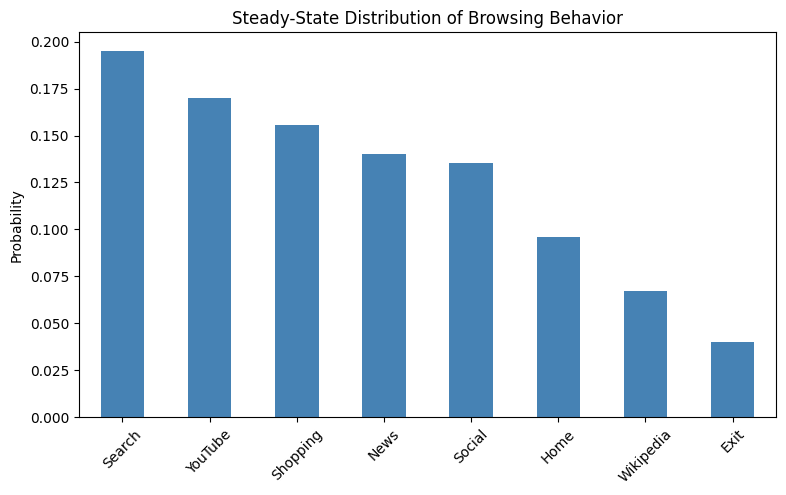

In [3]:
# Calculate stationary distribution
T = transition_matrix.values

eigenvalues, eigenvectors = np.linalg.eig(T.T)
stationary = np.real(eigenvectors[:, np.argmin(abs(eigenvalues - 1))])
stationary = stationary / stationary.sum()

steady_state = pd.Series(stationary, index=sites)

print("Long-term browsing distribution:")
display(steady_state.sort_values(ascending=False).round(3))

plt.figure(figsize=(9,5))
steady_state.sort_values(ascending=False).plot(kind="bar", color="steelblue")
plt.ylabel("Probability")
plt.title("Steady-State Distribution of Browsing Behavior")
plt.xticks(rotation=45)
plt.show()


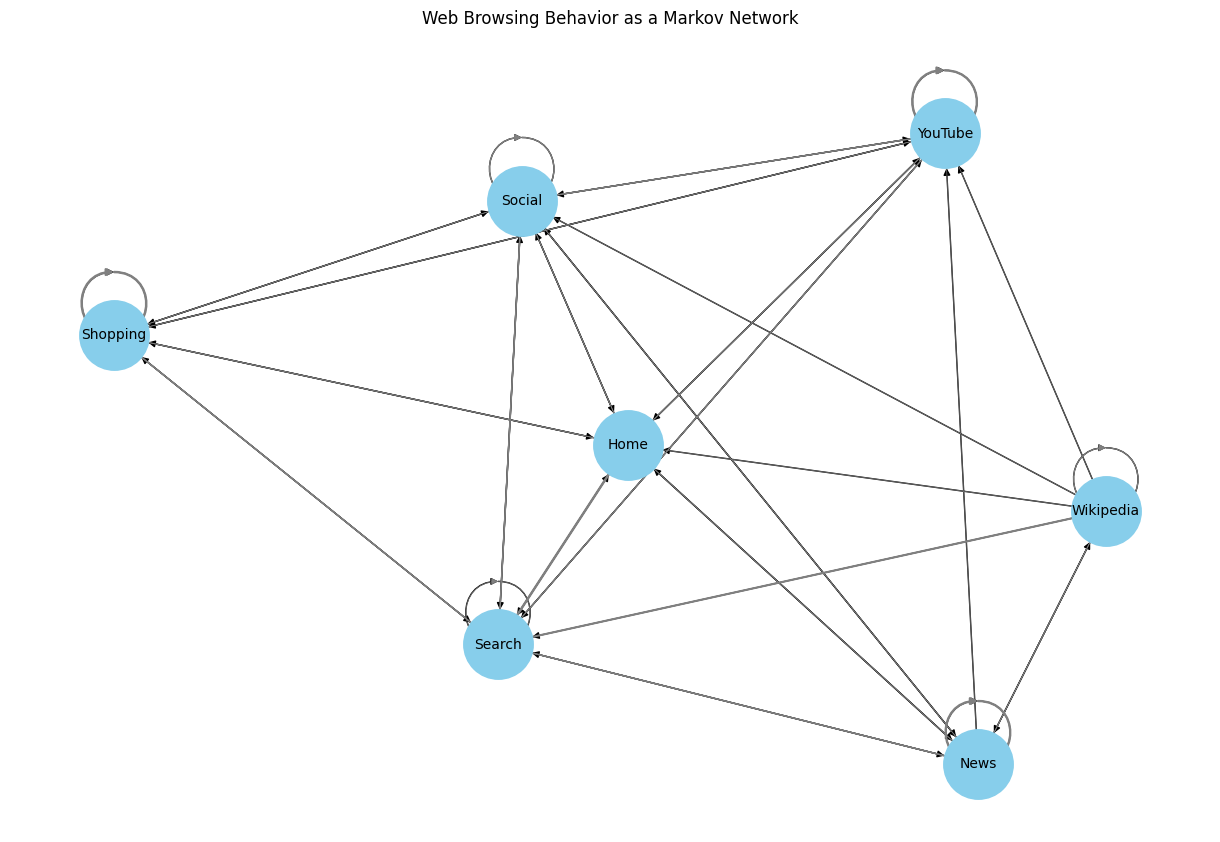

Top browsing transitions:
Shopping     → Shopping     : 0.361
Home         → Search       : 0.357
YouTube      → YouTube      : 0.343
News         → News         : 0.341
Wikipedia    → Search       : 0.298
Social       → Search       : 0.228
Social       → Social       : 0.195
Search       → Shopping     : 0.195
Social       → YouTube      : 0.195
News         → Search       : 0.194


In [4]:
# Create directed weighted graph
G = nx.DiGraph()

for i in sites:
    for j in sites:
        if transition_matrix.loc[i, j] > 0.08 and i != "Exit":
            G.add_edge(i, j, weight=transition_matrix.loc[i, j])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_color="skyblue",
    node_size=2500,
    font_size=10,
    arrows=True
)

weights = [G[u][v]["weight"] * 5 for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, edge_color="gray")

plt.title("Web Browsing Behavior as a Markov Network")
plt.show()

# Top transitions
transitions = []

for i in sites:
    for j in sites:
        if transition_matrix.loc[i,j] > 0:
            transitions.append((i, j, transition_matrix.loc[i,j]))

top = sorted(transitions, key=lambda x: x[2], reverse=True)[:10]

print("Top browsing transitions:")
for a, b, p in top:
    print(f"{a:12} → {b:12} : {p:.3f}")


In [6]:
from scipy.stats import chi2_contingency, ttest_ind

# -------------------------------
# TEST 1: Chi-Square Test
# -------------------------------
# Tests whether the current website and next website are independent.

# Exclude the 'Exit' row and column as it's an absorbing state and causes zero expected frequencies
chi2, p_value, dof, expected = chi2_contingency(counts.iloc[:-1, :-1])

print("CHI-SQUARE TEST")
print("-" * 40)
print(f"Chi-square statistic : {chi2:.3f}")
print(f"p-value              : {p_value:.6f}")
print(f"Degrees of freedom   : {dof}")

if p_value < 0.05:
    print("Result: Significant association between current and next website (excluding Exit).")
else:
    print("Result: No significant association detected (excluding Exit).")


# -------------------------------
# TEST 2: Independent t-test
# -------------------------------
# Compare session lengths of two groups of browsing sessions.

group1 = [len(s) for s in sessions[:500]]
group2 = [len(s) for s in sessions[500:]]

t_stat, t_pvalue = ttest_ind(group1, group2, equal_var=False)

print("\nINDEPENDENT T-TEST")
print("-" * 40)
print(f"Group 1 mean session length : {np.mean(group1):.3f}")
print(f"Group 2 mean session length : {np.mean(group2):.3f}")
print(f"t-statistic                 : {t_stat:.3f}")
print(f"p-value                     : {t_pvalue:.6f}")

if t_pvalue < 0.05:
    print("Result: Significant difference between session lengths.")
else:
    print("Result: No significant difference between session lengths.")

CHI-SQUARE TEST
----------------------------------------
Chi-square statistic : 2721.941
p-value              : 0.000000
Degrees of freedom   : 36
Result: Significant association between current and next website (excluding Exit).

INDEPENDENT T-TEST
----------------------------------------
Group 1 mean session length : 12.496
Group 2 mean session length : 13.156
t-statistic                 : -2.347
p-value                     : 0.019118
Result: Significant difference between session lengths.
